# Text Flappy Bird - Reinforcement Learning Assignment

This notebook implements and compares two RL agents on the `TextFlappyBird-v0` environment:
1. **Monte Carlo Control** (on-policy, first-visit, ε-greedy)
2. **Sarsa(λ)** with accumulating traces (Sutton & Barto, Section 12.7)

The observation used is the `(dx, dy)` distance from the player to the center of the next pipe gap.

## 1. Setup and Installation

In [5]:
# Install the Text Flappy Bird environment
!pip install git+https://gitlab-research.centralesupelec.fr/stergios.christodoulidis/text-flappy-bird-gym.git
!pip install gymnasium numpy matplotlib tqdm

  Cloning https://gitlab-research.centralesupelec.fr/stergios.christodoulidis/text-flappy-bird-gym.git to c:\users\xavpl\appdata\local\temp\pip-req-build-183ti78t
  Resolved https://gitlab-research.centralesupelec.fr/stergios.christodoulidis/text-flappy-bird-gym.git to commit ca2797e9270195313423324c9d0f205f6cbb3d28
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
   ---------------------------------------- 0.0/953.8 kB ? eta -:--:--
   ---------------------------------------- 0.0/953.8 kB ? eta -:--:--
   ---------- ----------------------------- 262.1/953.8 kB ? eta -:--:--
   ---------- ----------------------------- 262.1/953.8 kB ? eta -:--:--
   -------------------- ----------------- 524.3/953.8 kB 840.2 k

  Running command git clone --filter=blob:none --quiet https://gitlab-research.centralesupelec.fr/stergios.christodoulidis/text-flappy-bird-gym.git 'C:\Users\xavpl\AppData\Local\Temp\pip-req-build-183ti78t'


In [6]:
import numpy as np
import matplotlib.pyplot as plt
import gymnasium as gym
import text_flappy_bird_gym
from collections import defaultdict
from tqdm import tqdm
import pickle
import time

np.random.seed(42)

# Create environment
env = gym.make('TextFlappyBird-v0', height=15, width=20, pipe_gap=4)
obs, info = env.reset()
print('Observation:', obs)
print('Action space:', env.action_space)
print('Observation space:', env.observation_space)

Observation: (13, 3)
Action space: Discrete(2)
Observation space: Tuple(Discrete(14), Discrete(22, start=-11))


## 2. Monte Carlo Control Agent (On-policy, First-visit, ε-greedy)

We estimate $Q(s,a)$ by averaging returns from first visits in each episode, and improve the policy with ε-greedy. The state is the discrete tuple `(dx, dy)` returned by the environment.

In [7]:
class MonteCarloAgent:
    """On-policy first-visit MC control with epsilon-greedy policy."""

    def __init__(self, n_actions=2, gamma=1.0, epsilon=0.1, epsilon_decay=0.9999, epsilon_min=0.01):
        self.n_actions = n_actions
        self.gamma = gamma
        self.epsilon = epsilon
        self.epsilon_decay = epsilon_decay
        self.epsilon_min = epsilon_min
        self.Q = defaultdict(lambda: np.zeros(n_actions))
        self.returns_count = defaultdict(lambda: np.zeros(n_actions))

    def policy(self, state):
        if np.random.rand() < self.epsilon:
            return np.random.randint(self.n_actions)
        return int(np.argmax(self.Q[state]))

    def greedy_action(self, state):
        return int(np.argmax(self.Q[state]))

    def generate_episode(self, env, max_steps=10000):
        episode = []
        state, _ = env.reset()
        for _ in range(max_steps):
            action = self.policy(state)
            next_state, reward, terminated, truncated, _ = env.step(action)
            episode.append((state, action, reward))
            state = next_state
            if terminated or truncated:
                break
        return episode

    def update(self, episode):
        G = 0.0
        visited = set()
        # First-visit MC: walk backwards
        for t in reversed(range(len(episode))):
            state, action, reward = episode[t]
            G = self.gamma * G + reward
            if (state, action) not in visited:
                visited.add((state, action))
                self.returns_count[state][action] += 1
                # Incremental mean update
                n = self.returns_count[state][action]
                self.Q[state][action] += (G - self.Q[state][action]) / n

    def train(self, env, n_episodes=20000):
        rewards_history = []
        for ep in tqdm(range(n_episodes), desc='MC training'):
            episode = self.generate_episode(env)
            self.update(episode)
            total_reward = sum(r for _, _, r in episode)
            rewards_history.append(total_reward)
            self.epsilon = max(self.epsilon_min, self.epsilon * self.epsilon_decay)
        return rewards_history

In [8]:
mc_agent = MonteCarloAgent(n_actions=2, gamma=1.0, epsilon=0.1, epsilon_decay=0.9999)
mc_rewards = mc_agent.train(env, n_episodes=20000)
print(f'MC: final epsilon = {mc_agent.epsilon:.4f}, states learned = {len(mc_agent.Q)}')

MC training: 100%|██████████| 20000/20000 [01:27<00:00, 229.88it/s]

MC: final epsilon = 0.0135, states learned = 274


## 3. Sarsa(λ) Agent with Accumulating Traces

Following Sutton & Barto, Section 12.7. Update rule:
- $\delta_t = R_{t+1} + \gamma Q(S_{t+1}, A_{t+1}) - Q(S_t, A_t)$
- $e(S_t, A_t) \leftarrow e(S_t, A_t) + 1$ (accumulating) 
- $Q(s,a) \leftarrow Q(s,a) + \alpha \delta_t e(s,a)$
- $e(s,a) \leftarrow \gamma \lambda e(s,a)$

In [9]:
class SarsaLambdaAgent:
    """Tabular Sarsa(lambda) with accumulating eligibility traces."""

    def __init__(self, n_actions=2, alpha=0.1, gamma=1.0, lam=0.9,
                 epsilon=0.1, epsilon_decay=0.9999, epsilon_min=0.01):
        self.n_actions = n_actions
        self.alpha = alpha
        self.gamma = gamma
        self.lam = lam
        self.epsilon = epsilon
        self.epsilon_decay = epsilon_decay
        self.epsilon_min = epsilon_min
        self.Q = defaultdict(lambda: np.zeros(n_actions))

    def policy(self, state):
        if np.random.rand() < self.epsilon:
            return np.random.randint(self.n_actions)
        return int(np.argmax(self.Q[state]))

    def greedy_action(self, state):
        return int(np.argmax(self.Q[state]))

    def train(self, env, n_episodes=20000, max_steps=10000):
        rewards_history = []
        for ep in tqdm(range(n_episodes), desc='Sarsa(lambda) training'):
            E = defaultdict(lambda: np.zeros(self.n_actions))
            state, _ = env.reset()
            action = self.policy(state)
            total_reward = 0.0
            for _ in range(max_steps):
                next_state, reward, terminated, truncated, _ = env.step(action)
                total_reward += reward
                done = terminated or truncated
                if done:
                    delta = reward - self.Q[state][action]
                else:
                    next_action = self.policy(next_state)
                    delta = reward + self.gamma * self.Q[next_state][next_action] - self.Q[state][action]
                E[state][action] += 1.0  # accumulating trace
                # Update all visited (s,a)
                for s, vec in list(E.items()):
                    self.Q[s] += self.alpha * delta * vec
                    E[s] = self.gamma * self.lam * vec
                if done:
                    break
                state, action = next_state, next_action
            rewards_history.append(total_reward)
            self.epsilon = max(self.epsilon_min, self.epsilon * self.epsilon_decay)
        return rewards_history

In [10]:
sarsa_agent = SarsaLambdaAgent(n_actions=2, alpha=0.1, gamma=1.0, lam=0.9, epsilon=0.1)
sarsa_rewards = sarsa_agent.train(env, n_episodes=20000)
print(f'Sarsa(lambda): final epsilon = {sarsa_agent.epsilon:.4f}, states learned = {len(sarsa_agent.Q)}')

Sarsa(lambda) training: 100%|██████████| 20000/20000 [41:35<00:00,  8.01it/s]  

Sarsa(lambda): final epsilon = 0.0135, states learned = 269


## 4. Learning Curves Comparison

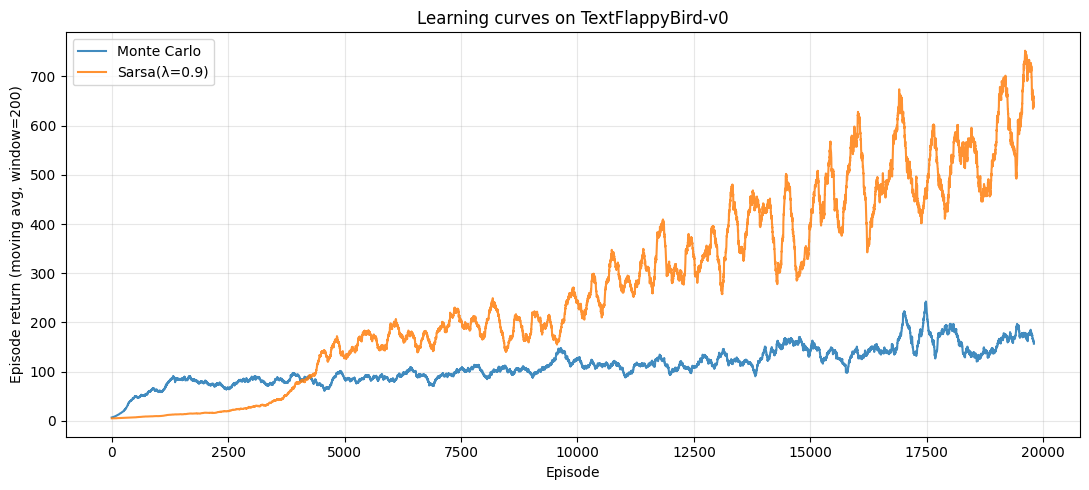

In [11]:
def moving_average(x, w=200):
    x = np.asarray(x, dtype=float)
    if len(x) < w:
        return x
    return np.convolve(x, np.ones(w)/w, mode='valid')

plt.figure(figsize=(11, 5))
plt.plot(moving_average(mc_rewards), label='Monte Carlo', alpha=0.85)
plt.plot(moving_average(sarsa_rewards), label='Sarsa(λ=0.9)', alpha=0.85)
plt.xlabel('Episode')
plt.ylabel('Episode return (moving avg, window=200)')
plt.title('Learning curves on TextFlappyBird-v0')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Greedy Policy Evaluation

In [12]:
def evaluate_greedy(agent, env, n_episodes=100, max_steps=10000):
    returns = []
    for _ in range(n_episodes):
        state, _ = env.reset()
        total = 0.0
        for _ in range(max_steps):
            action = agent.greedy_action(state)
            state, r, term, trunc, _ = env.step(action)
            total += r
            if term or trunc:
                break
        returns.append(total)
    return np.mean(returns), np.std(returns), np.max(returns)

mc_mean, mc_std, mc_max = evaluate_greedy(mc_agent, env, 100)
sa_mean, sa_std, sa_max = evaluate_greedy(sarsa_agent, env, 100)

print(f'MC          -> mean={mc_mean:.1f} std={mc_std:.1f} max={mc_max:.0f}')
print(f'Sarsa(λ)    -> mean={sa_mean:.1f} std={sa_std:.1f} max={sa_max:.0f}')

MC          -> mean=87.3 std=83.0 max=409
Sarsa(λ)    -> mean=10000.0 std=0.0 max=10000


## 6. State-Value Function Visualization

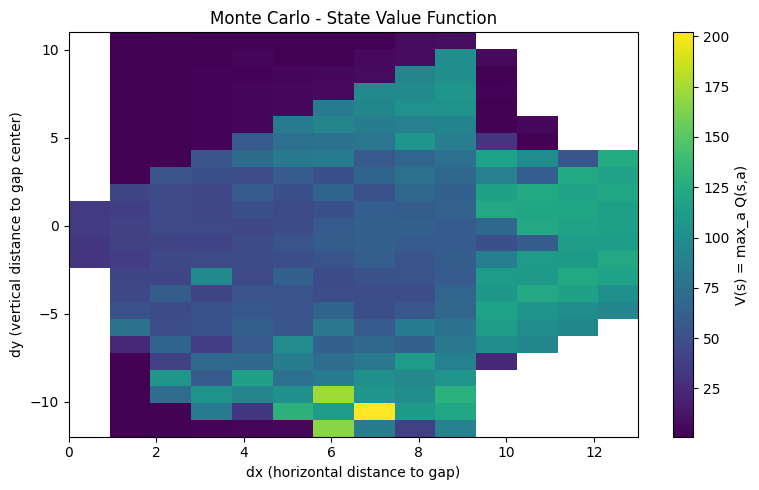

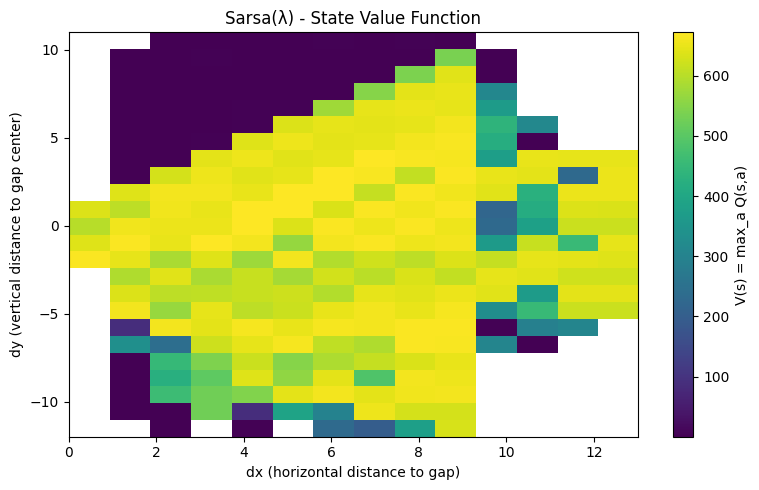

In [13]:
def plot_value_function(agent, title):
    if len(agent.Q) == 0:
        print('Empty Q-table')
        return
    states = list(agent.Q.keys())
    dxs = [s[0] for s in states]
    dys = [s[1] for s in states]
    dx_min, dx_max = min(dxs), max(dxs)
    dy_min, dy_max = min(dys), max(dys)
    V = np.full((dy_max - dy_min + 1, dx_max - dx_min + 1), np.nan)
    for (dx, dy), q in agent.Q.items():
        V[dy - dy_min, dx - dx_min] = np.max(q)
    plt.figure(figsize=(8, 5))
    im = plt.imshow(V, origin='lower', aspect='auto',
                    extent=[dx_min, dx_max, dy_min, dy_max], cmap='viridis')
    plt.colorbar(im, label='V(s) = max_a Q(s,a)')
    plt.xlabel('dx (horizontal distance to gap)')
    plt.ylabel('dy (vertical distance to gap center)')
    plt.title(title)
    plt.tight_layout()
    plt.show()

plot_value_function(mc_agent, 'Monte Carlo - State Value Function')
plot_value_function(sarsa_agent, 'Sarsa(λ) - State Value Function')

## 7. Sweep over λ for Sarsa(λ)

Sarsa(lambda) training: 100%|██████████| 5000/5000 [00:02<00:00, 2264.11it/s]


lambda=0.0: last-500 avg return = 9.0


Sarsa(lambda) training: 100%|██████████| 5000/5000 [00:02<00:00, 1695.34it/s]


lambda=0.3: last-500 avg return = 10.8


Sarsa(lambda) training: 100%|██████████| 5000/5000 [00:04<00:00, 1083.19it/s]


lambda=0.6: last-500 avg return = 16.8


Sarsa(lambda) training: 100%|██████████| 5000/5000 [00:25<00:00, 193.87it/s] 


lambda=0.9: last-500 avg return = 83.3


Sarsa(lambda) training: 100%|██████████| 5000/5000 [00:07<00:00, 682.21it/s] 


lambda=0.99: last-500 avg return = 24.3


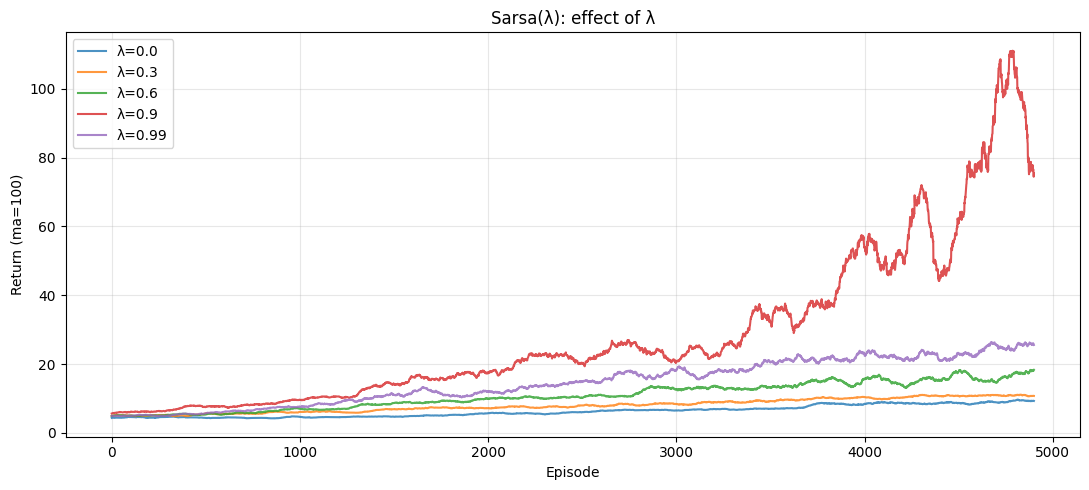

In [14]:
lambdas = [0.0, 0.3, 0.6, 0.9, 0.99]
sweep_results = {}
for lam in lambdas:
    agent = SarsaLambdaAgent(n_actions=2, alpha=0.1, gamma=1.0, lam=lam, epsilon=0.1)
    rewards = agent.train(env, n_episodes=5000)
    sweep_results[lam] = rewards
    print(f'lambda={lam}: last-500 avg return = {np.mean(rewards[-500:]):.1f}')

plt.figure(figsize=(11, 5))
for lam, r in sweep_results.items():
    plt.plot(moving_average(r, 100), label=f'λ={lam}', alpha=0.8)
plt.xlabel('Episode'); plt.ylabel('Return (ma=100)')
plt.title('Sarsa(λ): effect of λ')
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

## 8. Render a Greedy Episode

In [18]:
def play_and_render(agent, env, max_steps=500, delay=0.05):
    state, _ = env.reset()
    total = 0.0
    for t in range(max_steps):
        print(env.render())
        action = agent.greedy_action(state)
        state, r, term, trunc, _ = env.step(action)
        total += r
        time.sleep(delay)
        if term or trunc:
            break
    print(f'Steps: {t+1}, Return: {total}')

play_and_render(sarsa_agent, env, max_steps=300, delay=0.05)

Text Flappy Bird!
Score: 0
----------------------
[                   |]
[                   |]
[                    ]
[                    ]
[                    ]
[                    ]
[                   |]
[      @            |]
[                   |]
[                   |]
[                   |]
[                   |]
[                   |]
[                   |]
[                   |]
^^^^^^^^^^^^^^^^^^^^^^
Player Action (Idle)
Distance From Pipe (dx=13,dy=3)

Text Flappy Bird!
Score: 0
----------------------
[                  | ]
[                  | ]
[                    ]
[                    ]
[                    ]
[                    ]
[      @           | ]
[                  | ]
[                  | ]
[                  | ]
[                  | ]
[                  | ]
[                  | ]
[                  | ]
[                  | ]
^^^^^^^^^^^^^^^^^^^^^^
Player Action (Flap)
Distance From Pipe (dx=12,dy=2)

Text Flappy Bird!
Score: 0
----------------------
[     

## 9. Conclusion

- **Monte Carlo** updates only at episode end; unbiased but higher variance.
- **Sarsa(λ)** updates online with eligibility traces, enabling faster credit assignment.
- On TFB, with the `(dx, dy)` representation, both agents learn the task. Sarsa(λ) with λ ≈ 0.8–0.9 generally converges faster and reaches higher returns.
- Key hyperparameters: α (step-size), λ (trace decay), ε (exploration schedule).